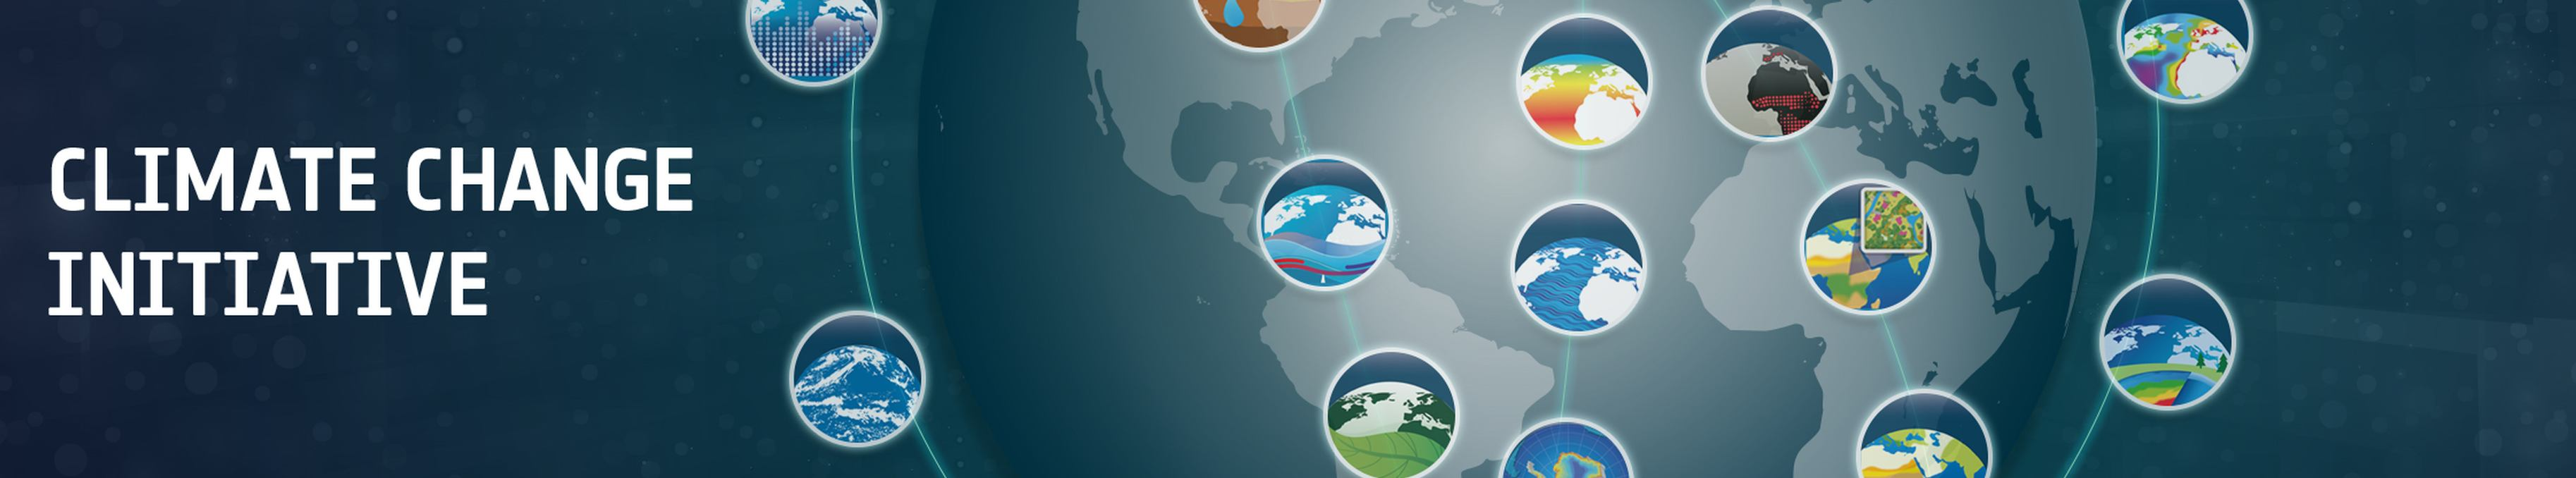

# Getting Started with Biomass CCI Data

### 1. Import Necessary Packages

In this section, we import the required Python packages to work with ESA Climate Change Initiative (CCI) data. Most notably, we use the [ESA Climate Toolbox](https://esa-climate-toolbox.readthedocs.io/en/latest/) which simplifies access, manipulation, and visualization of CCI datasets in Python.

These packages allow us to:
- Access satellite-based climate data records from ESA.
- Handle geospatial and temporal dimensions efficiently.
- Visualize data with intuitive plotting tools.

📚 For a broader introduction to the toolbox and how to install it, visit:  
🔗 [ESA CCI Climate Toolbox Quick Start](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks)  
🔗 [ESA Climate Data Toolbox Website](https://climate.esa.int/en/data/toolbox/)

In [1]:
from xcube.core.store import new_data_store
from esa_climate_toolbox.core import get_op
from esa_climate_toolbox.core import list_ecv_datasets
from esa_climate_toolbox.core import get_store
from esa_climate_toolbox.core import list_datasets
from esa_climate_toolbox.ops import plot
from esa_climate_toolbox.core import open_data           

import xarray as xr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") 
%matplotlib inline

### Step 2: Connect to the ESA CCI Data Store

The ESA Climate Toolbox provides direct access to the **ESA Climate Data Store**, which hosts harmonized satellite-based climate data records produced under the **ESA Climate Change Initiative (CCI)**.

In this step, we establish a connection to the data store so we can browse and open datasets. This connection allows us to access data **without having to download files manually** — a convenient way to explore and analyze large geospatial datasets in cloud-friendly formats such as **Zarr** or **Kerchunk**.

The data store includes a wide range of essential climate variables (ECVs), such as aerosols, land surface temperature, sea level, and soil moisture.

📘 Learn more about available datasets:  
🔗 [ESA Climate Data Toolbox – Quick Start Guide](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#data-access)

In [101]:
cci_store = new_data_store("esa-cci")
# List all available data sets of an ECV
# list_ecv_datasets("Biomass")

### Step 3: Define the Dataset ID  
To work with a specific ESA CCI dataset, we need to specify its **dataset ID**. This unique identifier tells the toolbox which variable and product we want to access.

In this example, we are using a dataset that provides **Above-Ground Biomass (AGB)**, derived from a combination of multiple sensors and platforms. AGB is a key Essential Climate Variable (ECV) used to estimate the amount of carbon stored in vegetation, supporting studies related to the global carbon cycle, deforestation, and land use change.

For other ESA CCI projects (e.g., Land Cover, Soil Moisture, Sea Surface Temperature), simply replace the dataset ID accordingly.

📘 A full list of dataset IDs can be retrieved from the store or found in the [ESA CCI Climate Toolbox documentation](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#accessing-data).

In [94]:
data_id = 'esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.7-0.10000m'

This product provides annual AGB estimates at 10000m resolution, covering the period from 2005 to 2024.

### Step 4: Describe Dataset (Check Available Variables and Metadata)

Before loading the full dataset, it’s helpful to **inspect the metadata** to understand its structure. This includes:

- Available variables (e.g., agb, uncertainty estimates)
- Temporal and spatial coverage
- Data format and structure

This step ensures we know what the dataset contains and how to work with it. It also helps confirm that the variable we want to plot or analyze is actually included.

🛠️ Tip: You can use the description to verify variable names, dimensions (e.g., `lat`, `lon`, `time`), and time coverage.

📘 More on dataset structure:  
🔗 [ESA Climate Toolbox – Data Access](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#accessing-data)

In [4]:
cci_store.describe_data(data_id)

### Step 5: Check Open Parameters for the Dataset

Before opening the dataset, we can inspect which parameters are supported by the **Zarr opener** (e.g., `time_range`, `bbox`, `variable_names`). This step helps ensure that we pass valid arguments when loading data and avoid errors.

The command below lists all expected input parameters and their allowed values for the selected dataset.

In [5]:
cci_store.get_open_data_params_schema(data_id=data_id, opener_id='dataset:zarr:cciodp')

### Step 6: Define Region, Time Range, and Variables of Interest

Before opening the dataset, we define a few key parameters:

- **Time range**: the date(s) we want to load
- **Variables**: which data variable(s) to retrieve
- *(Optional)* **Bounding box**: spatial region of interest — here we skip it to load the global dataset

In [86]:
variables = ['agb']  # Variable to retrieve
start_date = '2014-01-01'    # Start and end date (same for a single timestep)
end_date = '2024-12-31'

### Step 7: Open the Dataset

Now we open the dataset using the selected parameters.  
The ESA Climate Toolbox will download only the necessary data (e.g., variable and time range).
You can always adjust the time range or variables to explore different slices of the dataset.

In [87]:
biomass_ds, biomass_name = open_data(data_id,var_names=variables,time_range=[start_date, end_date])
biomass_ds

<xarray.Dataset> Size: 467MB
Dimensions:    (time: 18, lat: 1800, lon: 3600, nv: 2, bnds: 2)
Coordinates:
  * lat        (lat) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
    lat_bnds   (lat, nv) float64 29kB dask.array<chunksize=(1800, 2), meta=np.ndarray>
  * lon        (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    lon_bnds   (lon, nv) float64 58kB dask.array<chunksize=(3600, 2), meta=np.ndarray>
  * time       (time) datetime64[ns] 144B 2005-07-02 ... 2024-07-01T12:00:00
    time_bnds  (time, bnds) datetime64[ns] 288B dask.array<chunksize=(18, 2), meta=np.ndarray>
Dimensions without coordinates: nv, bnds
Data variables:
    agb        (time, lat, lon) float32 467MB dask.array<chunksize=(18, 450, 450), meta=np.ndarray>
    crs        <U0 0B ...
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-plat...
    date_created:            2026-05-27T11:43:34.508989
    processing_level:        L4
    time_coverage_start:     2005-01-01T00:00:00
    time_coverage_end:       2024-12-31T00:00:00
    time_coverage_duration:  P7304DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

### Step 8: Display Dataset Structure

We print a summary of the opened dataset to inspect its structure, dimensions, variables, and metadata.  
This helps verify that the data was loaded correctly and shows what is available for analysis and visualization.
This step is useful to understand what the dataset contains before working with it further.

In [88]:
print("\nOpened Dataset:\n", biomass_ds)


Opened Dataset:
 <xarray.Dataset> Size: 467MB
Dimensions:    (time: 18, lat: 1800, lon: 3600, nv: 2, bnds: 2)
Coordinates:
  * lat        (lat) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
    lat_bnds   (lat, nv) float64 29kB dask.array<chunksize=(1800, 2), meta=np.ndarray>
  * lon        (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    lon_bnds   (lon, nv) float64 58kB dask.array<chunksize=(3600, 2), meta=np.ndarray>
  * time       (time) datetime64[ns] 144B 2005-07-02 ... 2024-07-01T12:00:00
    time_bnds  (time, bnds) datetime64[ns] 288B dask.array<chunksize=(18, 2), meta=np.ndarray>
Dimensions without coordinates: nv, bnds
Data variables:
    agb        (time, lat, lon) float32 467MB dask.array<chunksize=(18, 450, 450), meta=np.ndarray>
    crs        <U0 0B ...
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-plat...
    date_created:            2026-05-27T11:43:34.508989
    proc

### Step 9: Visualize Results

We now create a simple map plot of the selected variable.  
This allows us to explore the spatial patterns of the data — in this case, the above ground biomass (agb) for the selected day.
For more interactive and advanced visualisations, check out the [ESA Climate Toolbox](https://climate.esa.int/en/data/toolbox/) or the [Toolbox documentation](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks).

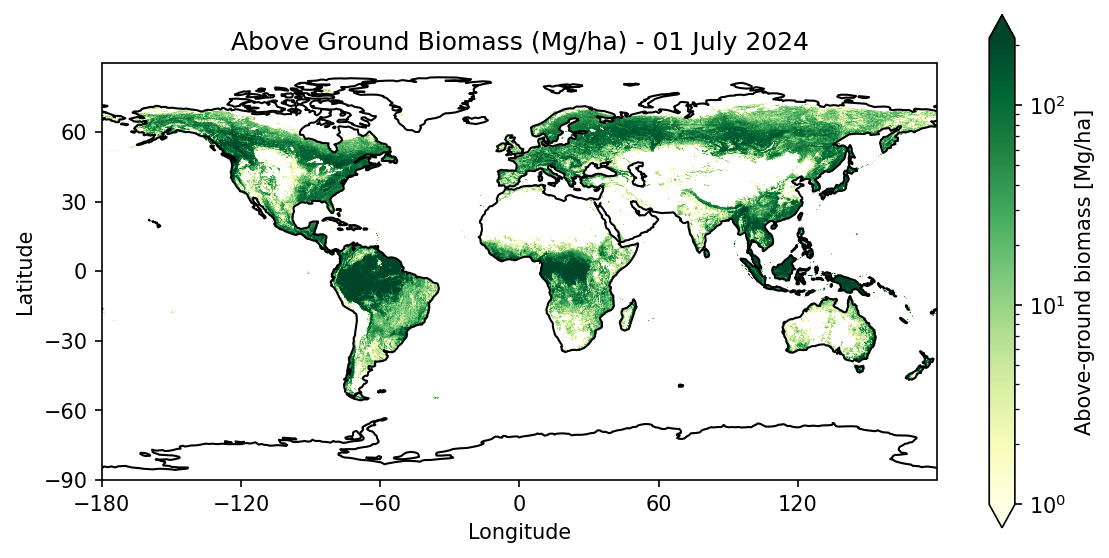

In [107]:
from datetime import datetime
# chosing a date for the plot and retrieving the closest time from the dataset to assure the correct date is shown in the figure title
timestep = '2024-01-01'
time_str = biomass_ds['time'].sel(time='2024-01-01',method="nearest").dt.strftime('%d %B %Y').item()

# increasing the resolution of the figure 
plt.rcParams['figure.dpi'] = 150  

# getting the plotting operator from the toolbox
plot_map = get_op('plot_map')

plot_map(
    biomass_ds.sel(time=timestep, method='nearest'), 
    var="agb",
    projection="PlateCarree", 
    title="Above Ground Biomass (Mg/ha) - " + time_str,
    properties=dict(cmap="YlGn", 
                    shading="auto",
                    xticks=np.arange(-180, 180, 60), 
                    yticks=np.arange(-90, 90, 30),
                    norm=plt.matplotlib.colors.LogNorm(vmin=1, vmax=np.nanpercentile(biomass_ds["agb"], 99))
                    )
)
plt.gca().set_xlabel("Longitude")
plt.gca().set_ylabel("Latitude")
plt.show()

### Step 10: The difference of Above Ground Biomass accross the years
In a next step, we can examine the change in above ground biomass above Germany between 2010 and 2020. 
To do so, we will load the biomass `DIFF` file with higher resolution of 1000 m as we will also reduce the dataset to a smaller spatial subset.

We start again by defining the data ID and inspecting the dataset.

In [108]:
data_id = 'esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.DIFF.7-0.1000m-2020-2010'
cci_store.describe_data(data_id)

The variable we would like to plot here is called `diff` which we will define when opening the dataset. Additionally, we will build a spatial subset with the toolbox to reduce the dataset to an area of interest. In this case, we focus on Germany and define the latitude and longitude boundaries with the toolbox.

In [109]:
# Building a subset for Germany and saving it into a new dataset 
bbox = [5.5, 47.2, 15.5, 55.1] # bounding box or Germany, the values are given as lon_min, lat_min, lon_max, lat_max

# Opening the data with the toolbox
biomass_diff, biomass_diff_name = open_data(data_id,var_names="diff")

# Calling the spatial subset operator
subset_spatial_op = get_op('subset_spatial')

# Applying the spatial subset operator on the biomass dataset with the above defined bbox
biomass_sub = subset_spatial_op(ds=biomass_diff, region=bbox)
biomass_sub

<xarray.Dataset> Size: 3MB
Dimensions:    (time: 1, lat: 791, lon: 1001, nv: 2, bnds: 2)
Coordinates:
  * lat        (lat) float64 6kB 55.1 55.09 55.08 55.07 ... 47.22 47.21 47.2
    lat_bnds   (lat, nv) float64 13kB dask.array<chunksize=(791, 2), meta=np.ndarray>
  * lon        (lon) float64 8kB 5.495 5.505 5.515 5.525 ... 15.47 15.49 15.5
    lon_bnds   (lon, nv) float64 16kB dask.array<chunksize=(1001, 2), meta=np.ndarray>
  * time       (time) datetime64[ns] 8B 2015-07-02T23:59:59
    time_bnds  (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: nv, bnds
Data variables:
    crs        <U0 0B ...
    diff       (time, lat, lon) float32 3MB dask.array<chunksize=(1, 511, 1001), meta=np.ndarray>
Attributes: (12/18)
    Conventions:                CF-1.7
    title:                      esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-p...
    date_created:               2026-05-27T12:38:25.311913
    processing_level:           L4
    time_coverage_start:        2010-01-01T00:00:00
    time_coverage_end:          2020-12-31T23:59:59
    ...                         ...
    geospatial_lat_resolution:  0.010000000000005116
    geospatial_lat_min:         47.21
    geospatial_lat_max:         55.099999999999994
    geospatial_lat_units:       degrees_north
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((5.490000000000009 47.21, 5.490000000...

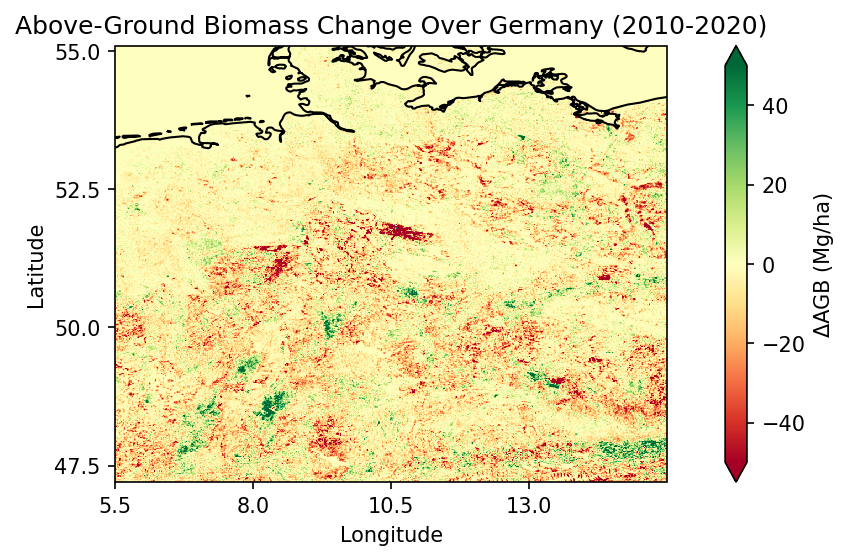

In [110]:
# defining the limits of the colorbar and the center of the colormap
norm = TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)

# defining the dates for the title by reading the data_id
start_year, end_year = data_id.split('-')[-2:]
dataset_year = f"{end_year}-{start_year}"


plot_map(
    biomass_sub, 
    var="diff",
    projection="PlateCarree", 
    title="Above-Ground Biomass Change Over Germany (" + dataset_year + ")",
    region=bbox,
    properties=dict(cmap="RdYlGn", 
                    shading="auto",
                    xticks=np.arange(5.5, 15.5, 2.5), 
                    yticks=np.arange(47.5, 55.5, 2.5),
                    norm=norm,
                    cbar_kwargs={       
                        "label": "ΔAGB (Mg/ha)"
                    }
                    )
)
plt.gca().set_xlabel("Longitude")
plt.gca().set_ylabel("Latitude")
plt.show()